# Brain Data Exploration

**CS231N Final Project — FA-KGD: Frequency-Adaptive Kalman-Guided Diffusion**

Explore the fastMRI brain multicoil validation data (AXT2, 384×384).
Verify data format, resolution, and RSS ground truth quality.

In [1]:
import sys
sys.path.insert(0, '../..')

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from src.samplers.mri_forward import fft2c, ifft2c

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../../data/brain_val')
h5_files = sorted(DATA_DIR.glob('*.h5'))
print(f'Found {len(h5_files)} brain volumes')

Found 10 brain volumes


## 1. Volume summary

In [2]:
for f in h5_files:
    with h5py.File(f, 'r') as hf:
        ks = hf['kspace'].shape
        rss_shape = hf['reconstruction_rss'].shape if 'reconstruction_rss' in hf else 'N/A'
        acq = hf.attrs.get('acquisition', 'unknown')
        print(f'{f.name:45s}  kspace={ks}  rss={rss_shape}  acq={acq}')

file_brain_AXT2_200_2000093.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_2000103.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_2000314.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_2000340.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_2000464.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_2000628.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_6001989.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_6002148.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_6002485.h5                 kspace=(16, 16, 768, 396)  rss=(16, 384, 384)  acq=AXT2
file_brain_AXT2_200_6002592.h5                 kspace=(16, 20, 768, 396) 

## 2. RSS ground truth visualization

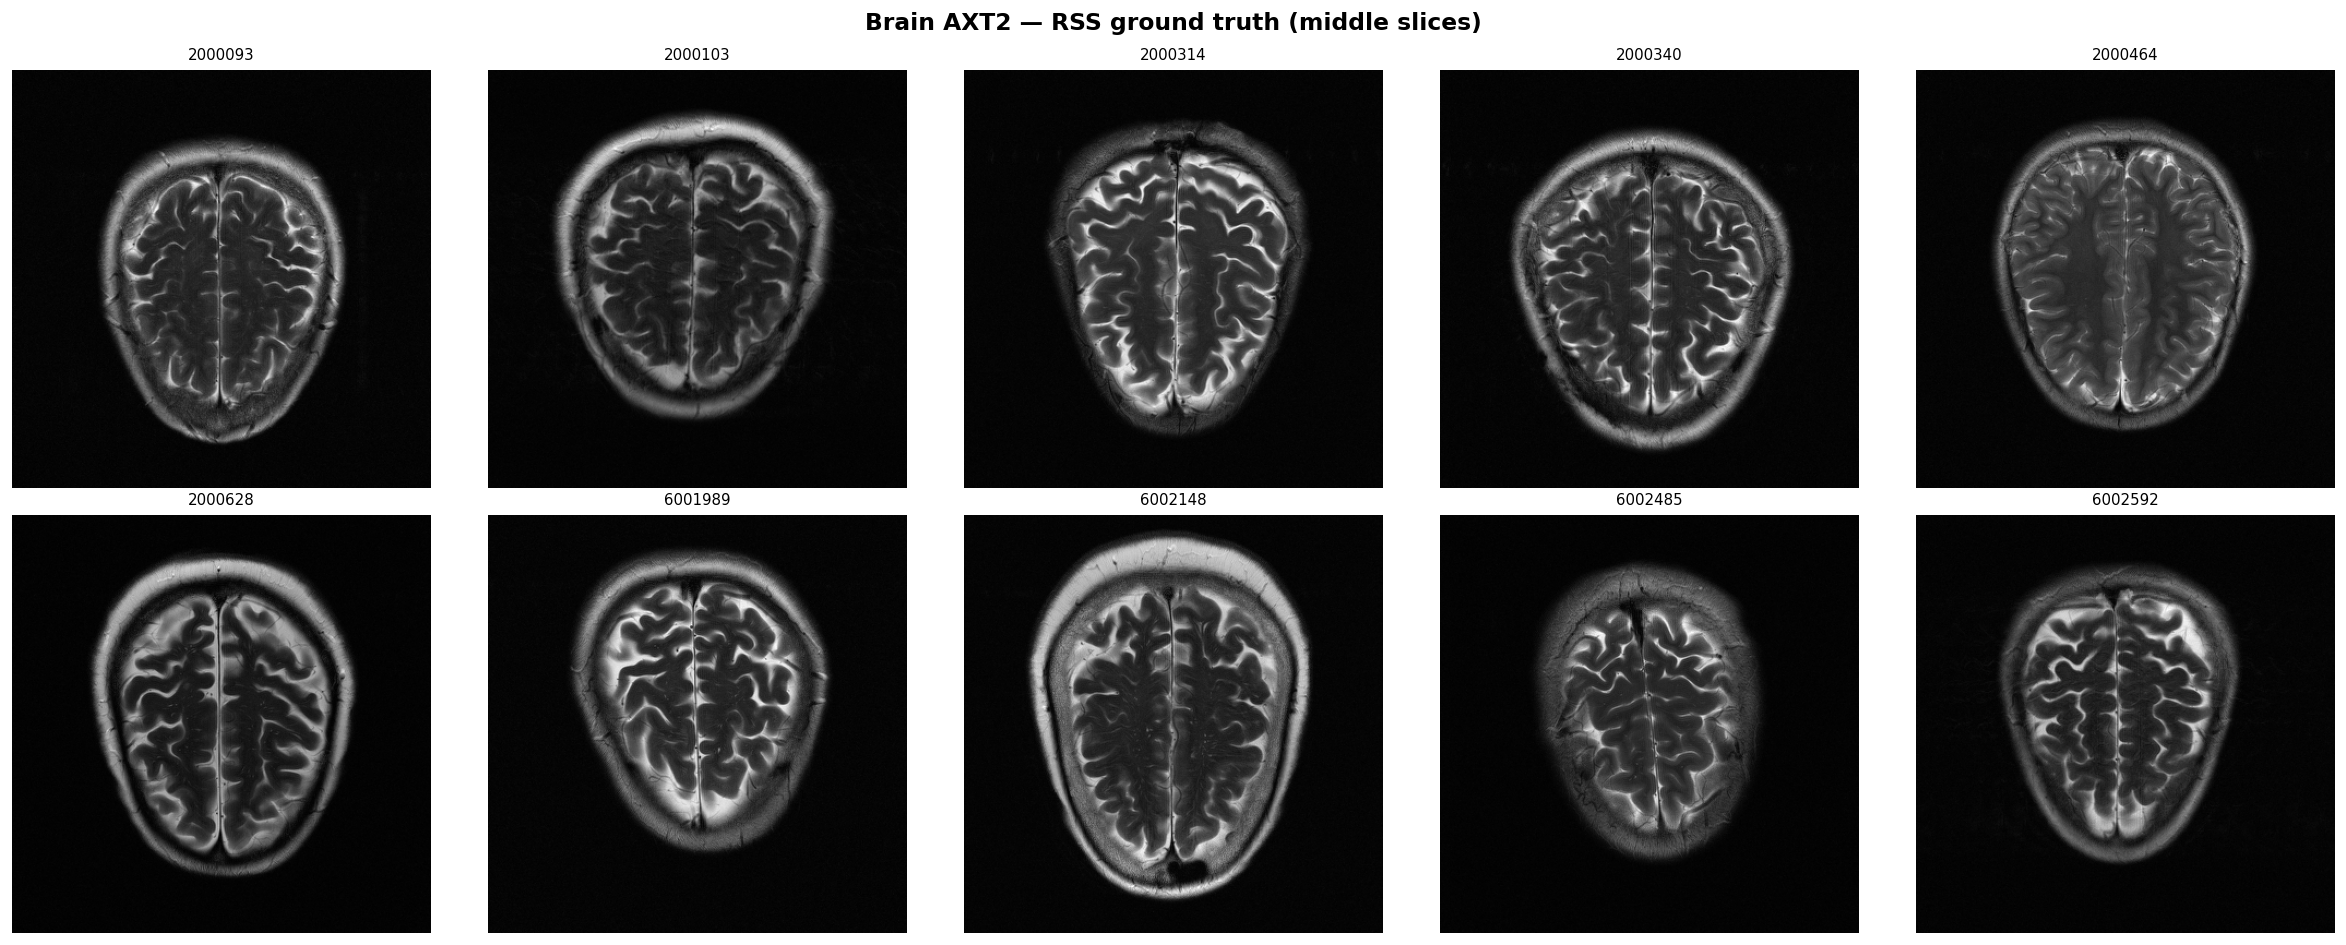

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, f in enumerate(h5_files):
    with h5py.File(f, 'r') as hf:
        rss = hf['reconstruction_rss']
        mid = rss.shape[0] // 2
        img = rss[mid]
    
    ax = axes[i // 5, i % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f.name.split('_')[-1].replace('.h5', ''), fontsize=9)
    ax.axis('off')

fig.suptitle('Brain AXT2 — RSS ground truth (middle slices)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Resolution and center crop check

Our EDM model expects 384×320. The brain data is 384×384, so we center-crop to 384×320.

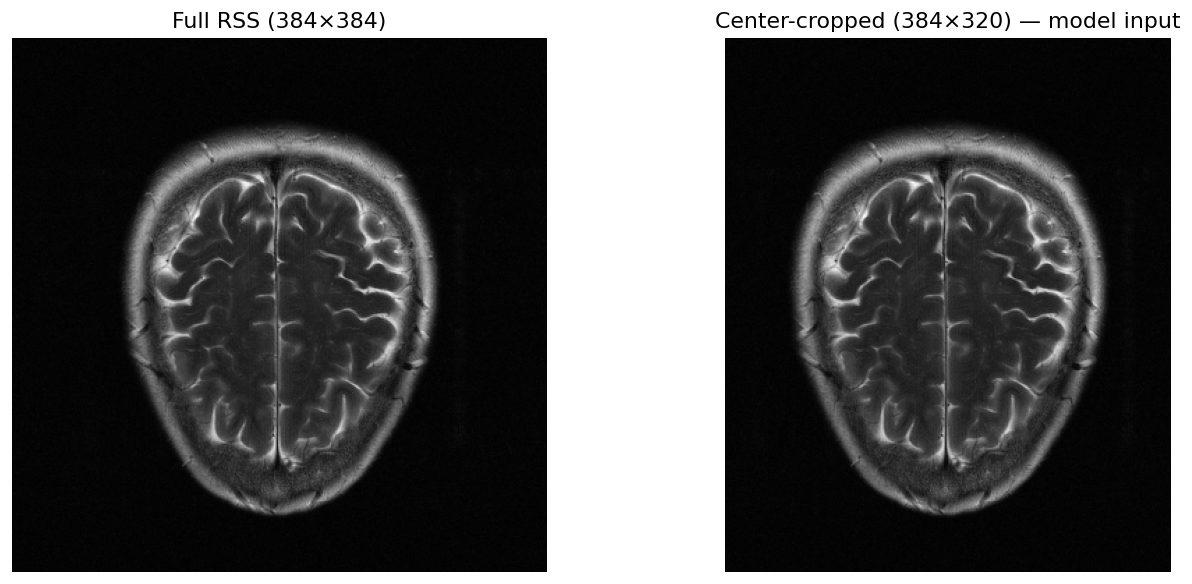

Crop removes 16.7% of columns (symmetric edge trimming)


In [4]:
# Show full vs center-cropped
with h5py.File(h5_files[0], 'r') as hf:
    rss = hf['reconstruction_rss'][:]
    mid = rss.shape[0] // 2
    full = rss[mid]  # 384x384

# Center crop to 384x320
H, W = full.shape
tW = 320
sw = (W - tW) // 2
cropped = full[:, sw:sw+tW]  # 384x320

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(full, cmap='gray')
axes[0].set_title(f'Full RSS ({H}×{W})')
axes[0].axis('off')

axes[1].imshow(cropped, cmap='gray')
axes[1].set_title(f'Center-cropped ({H}×{tW}) — model input')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(f'Crop removes {(1 - tW/W)*100:.1f}% of columns (symmetric edge trimming)')

## 4. Domain match check

The EDM model was trained on brain MRI at 384×320. This data is brain AXT2 at 384×384.
After center-cropping to 384×320, the domain should be well matched.

In [5]:
# Value range statistics
print(f'{"Volume":<45s} {"min":>8s} {"max":>8s} {"mean":>8s} {"std":>8s}')
print('-' * 80)
for f in h5_files:
    with h5py.File(f, 'r') as hf:
        rss = hf['reconstruction_rss'][:]
        # Center crop to 384x320
        W = rss.shape[-1]
        sw = (W - 320) // 2
        rss = rss[..., sw:sw+320]
        print(f'{f.name:<45s} {rss.min():>8.4f} {rss.max():>8.4f} {rss.mean():>8.4f} {rss.std():>8.4f}')

Volume                                             min      max     mean      std
--------------------------------------------------------------------------------
file_brain_AXT2_200_2000093.h5                  0.0000   0.0007   0.0001   0.0001
file_brain_AXT2_200_2000103.h5                  0.0000   0.0008   0.0001   0.0001
file_brain_AXT2_200_2000314.h5                  0.0000   0.0007   0.0001   0.0001
file_brain_AXT2_200_2000340.h5                  0.0000   0.0006   0.0001   0.0001
file_brain_AXT2_200_2000464.h5                  0.0000   0.0007   0.0001   0.0001
file_brain_AXT2_200_2000628.h5                  0.0000   0.0007   0.0001   0.0001
file_brain_AXT2_200_6001989.h5                  0.0000   0.0007   0.0001   0.0001
file_brain_AXT2_200_6002148.h5                  0.0000   0.0008   0.0001   0.0001
file_brain_AXT2_200_6002485.h5                  0.0000   0.0007   0.0001   0.0001
file_brain_AXT2_200_6002592.h5                  0.0000   0.0007   0.0001   0.0001
